### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***
 Report by
- Quyi Le -- `Quyi.Le@etu.univ-grenoble-alpes.fr`
- Olesia Zaichenko -- `olesia.zaichenko@etu.univ-grenoble-alpes.fr`
- Matvei Kudashev -- `matvei.kudashev@etu.univ-grenoble-alpes.fr`
***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

C:\Users\mak20\AppData\Local\Temp\ipykernel_33340\3072114253.py:3: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import multivariate_normal


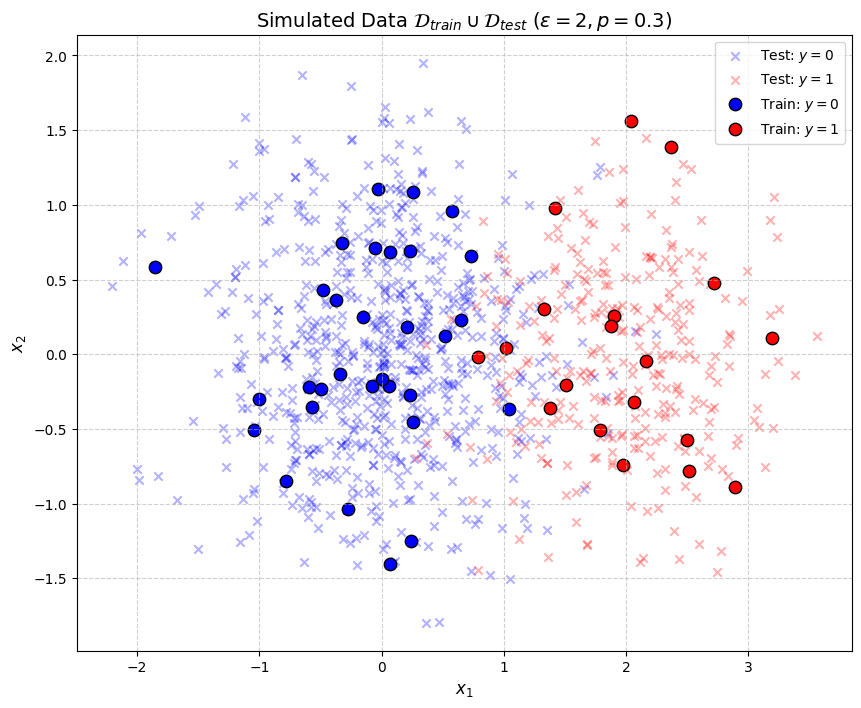

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

def generate_data(N, eps, p, seed=None):
    np.random.seed(seed)
    
    mu0 = np.array([0, 0])
    mu1 = np.array([eps, 0])
    Sigma0 = np.array([[0.5, 0], [0, 0.5]])
    Sigma1 = np.array([[0.4, 0], [0, 0.4]])
    
    U = np.random.rand(N)
    y = (U < p).astype(int)
    
    X = np.zeros((N, 2))
    sz = ((y==0).sum())
    X[y==0] = np.random.multivariate_normal(mu0, Sigma0, size=sz)
    X[y==1] = np.random.multivariate_normal(mu1, Sigma1, size=(N - sz))
    return X, y

np.random.seed(42)

epsilon = 2
p = 0.30

X_train, y_train = generate_data(50, epsilon, p, seed=42)

X_test, y_test = generate_data(1000, epsilon, p, seed=0)

plt.figure(figsize=(10, 8))

plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], 
            c='blue', marker='x', alpha=0.3, label='Test: $y=0$')
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], 
            c='red', marker='x', alpha=0.3, label='Test: $y=1$')

plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], 
            c='blue', marker='o', s=80, edgecolor='black', label='Train: $y=0$')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], 
            c='red', marker='o', s=80, edgecolor='black', label='Train: $y=1$')

plt.title(r'Simulated Data $\mathcal{D}_{train} \cup \mathcal{D}_{test}$ ($\varepsilon=2, p=0.3$)', fontsize=14)
plt.xlabel(r'$x_1$', fontsize=12)
plt.ylabel(r'$x_2$', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

We predict 1 if $P(Y=1 \mid x) > P(Y=0 \mid x)$, which is equivalent to $\frac{P(Y=1 \mid x)}{P(Y=0 \mid x)} > 1$

We know that $P(Y=k \mid x) = \frac{P(x \mid Y=k) \cdot P(Y=k)}{P(x)}$

By expanding the posterior probabilities into the product of the prior probabilities and the class-conditional probability density functions (PDFs), we get:
$$
\frac{\text{Prob}(Y=1 \mid \mathbf{x})}{\text{Prob}(Y=0 \mid \mathbf{x})} = \frac{p_{\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)}(\mathbf{x}) \cdot \text{Prob}(Y=1)}{p_{\mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0)}(\mathbf{x}) \cdot \text{Prob}(Y=0)}
$$

Given the priors $\text{Prob}(Y=1) = p$ and $\text{Prob}(Y=0) = 1-p$, the mathematical expression for the Bayes classifier $\hat{y}(\mathbf{x})$ is:
$$
\hat{y}(\mathbf{x}) = \begin{cases} 
1 & \text{if } \frac{p_{\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)}(\mathbf{x}) \cdot p}{p_{\mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0)}(\mathbf{x}) \cdot (1-p)} > 1 \\
0 & \text{otherwise}
\end{cases}
$$

The boundary region is defined by the set of points $\mathbf{x} \in \mathbb{R}^2$ where the decision ratio equals exactly $1$:
$$
\frac{p_{\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)}(\mathbf{x}) \cdot p}{p_{\mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0)}(\mathbf{x}) \cdot (1-p)} = 1,
$$

which is equaivalent to the equation below:
$$
\ln\left(p_{\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)}(\mathbf{x})\right) - \ln\left(p_{\mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0)}(\mathbf{x})\right) + \ln\left(\frac{p}{1-p}\right) = 0
$$

We expand each term and get:
$$
-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_1)^\top \boldsymbol{\Sigma}_1^{-1}(\mathbf{x}-\boldsymbol{\mu}_1) - \frac{1}{2}\ln(\det{\boldsymbol{\Sigma}_1}) + \frac{1}{2}(\mathbf{x}-\boldsymbol{\mu}_0)^\top \boldsymbol{\Sigma}_0^{-1}(\mathbf{x}-\boldsymbol{\mu}_0) + \frac{1}{2}\ln(\det{\boldsymbol{\Sigma}_0}) + \ln\left(\frac{p}{1-p}\right) = 0
$$

If $\Sigma_0 \neq \Sigma_1$ we get a quadratic equation in $x$, so the boundary is not linear. If $\Sigma_0 = \Sigma_1$, the quadratic terms cancel and we get a linear boundary. Substitute $\mu$ and $\Sigma$ we have:
$$
-\frac{1}{2} \left[ 2.5 \left( (x_1 - \varepsilon)^2 + x_2^2 \right) \right] - \frac{1}{2}\ln(0.16) + \frac{1}{2} \left[ 2 \left( x_1^2 + x_2^2 \right) \right] + \frac{1}{2}\ln(0.25) + \ln\left(\frac{p}{1-p}\right) = 0
$$

We then can simplify the equation as:
$$
x_1^2 + x_2^2 - 10\varepsilon x_1 + 5\varepsilon^2 + 2\ln(0.64) - 4\ln\left(\frac{p}{1-p}\right) = 0
$$

The geometric shape of this boundary is a **circle** in the $\mathbb{R}^2$ feature space.


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import multivariate_normal


class BayesClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, p, mu0, mu1, Sigma0, Sigma1):
        self.p = p
        self.mu0 = mu0
        self.mu1 = mu1
        self.Sigma0 = Sigma0
        self.Sigma1 = Sigma1

    def fit(self, X, y):
        return self

    def predict(self, X):
        p1 = self.p * multivariate_normal.pdf(X, self.mu1, self.Sigma1)
        p0 = (1 - self.p) * multivariate_normal.pdf(X, self.mu0, self.Sigma0)
        return (p1 >= p0).astype(int)

For small $\varepsilon$ the classes completely overlap, so the classifier cannot separate them (error is high). As $\varepsilon$  increases, points of different classes become more and more separable (error decreases). 

Bayes error (eps=2):  0.05930000000000002


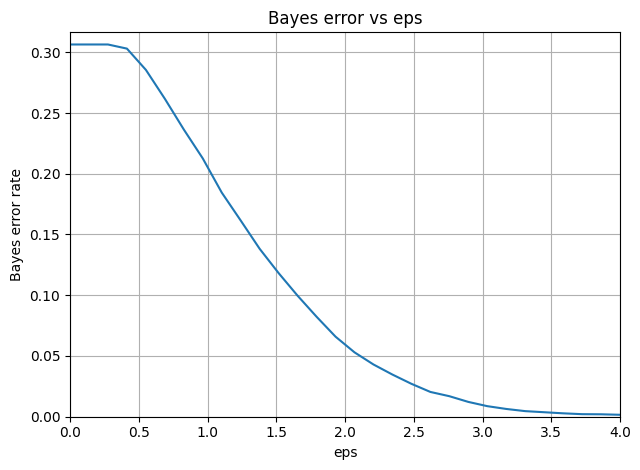

In [3]:
p = 0.3
eps = 2

X_eval, y_eval = generate_data(10000, eps=eps, p=p, seed=1)

mu0 = np.array([0, 0])
mu1 = np.array([eps, 0])
Sigma0 = np.array([[0.5, 0], [0, 0.5]])
Sigma1 = np.array([[0.4, 0], [0, 0.4]])

clf_bayes = BayesClassifier(p, mu0, mu1, Sigma0, Sigma1)
clf_bayes.fit(X_eval, y_eval)
bayes_err = 1 - clf_bayes.score(X_eval, y_eval)
print(f"Bayes error (eps={eps}): ", bayes_err)

epsilons = np.linspace(0, 4, 30)
errors = []
for eps in epsilons:
    mu1 = np.array([eps, 0])
    X_e, y_e = generate_data(10000, eps=eps, p=p, seed=1)
    clf = BayesClassifier(p, mu0, mu1, Sigma0, Sigma1)
    errors.append(1 - clf.score(X_e, y_e))

plt.plot(epsilons, errors)
plt.xlabel('eps')
plt.ylabel('Bayes error rate')
plt.title('Bayes error vs eps')
plt.tight_layout()
plt.grid()
plt.ylim(0, np.max(errors) + 0.01)
plt.xlim(0,4)
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

We will consider 3 classifiers: LDA, QDA and Logistic regression. 

- LDA assumes Gaussian distribution of x for each class, and a shared covariance matrix $\Sigma_0 = \Sigma_1$, which is not true in our case. Its linear boundary cannot capture the true quadratic boundary.

- QDA assumes that the distribution of x  -  is the Gaussian for each class, and each class has its own covariance matrix $\Sigma_k$. The boundary is quadratic.

- Logistic Regression makes no assumptions about the distribution of x at all, it models $P(Y=1∣x)$ directly as a sigmoid. The boundary is linear.

We think `QDA` is better since 
1. The data are generated by multi-variable normal distribution, which satisfies the condition to use DA.
2. They have different covariance matrix so it is better to use `QDA`


**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

classifiers = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'LogReg': LogisticRegression(),
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    err = 1 - clf.score(X_test, y_test)
    print(f"{name} test error: {err:.3f}")
print(f"Bayes error: {bayes_err:.3f}")

LDA test error: 0.073
QDA test error: 0.075
LogReg test error: 0.073
Bayes error: 0.059


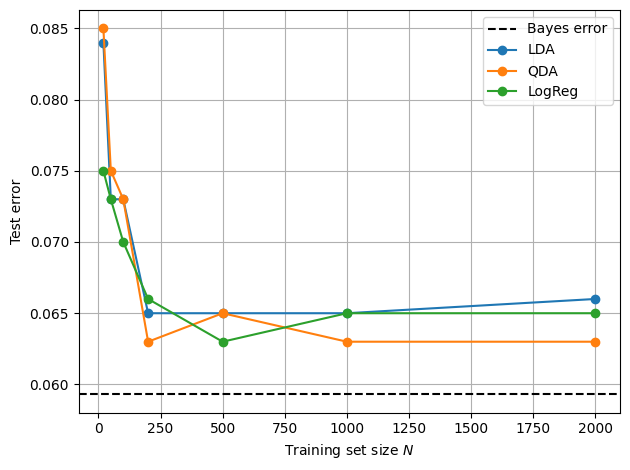

In [5]:
train_sizes = [20, 50, 100, 200, 500, 1000, 2000]
results = {name: [] for name in classifiers}

for N in train_sizes:
    X_tr, y_tr = generate_data(N, eps=2, p=0.30, seed=42)
    for name, clf in classifiers.items():
        clf.fit(X_tr, y_tr)
        results[name].append(1 - clf.score(X_test, y_test))

plt.axhline(bayes_err, color='k', linestyle='--', label='Bayes error')
for name, errs in results.items():
    plt.plot(train_sizes, errs, marker='o', label=name)
plt.xlabel('Training set size $N$')
plt.ylabel('Test error')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

At $N=50$, all three classifiers have errors above the Bayes error due to estimation variance. As $N$ grows, variance decreases and errors converge to their asymptotic values.

QDA converges to the Bayes error because its assumptions exactly match the generative model (Guassian x for each class + different covariance matrixes).
LDA converges to a higher asymptotic error, as it assumes $\Sigma_0 = \Sigma_1$. And logistic regression has a linear boundary while the true boundary is quadratic, so it also converges to a higher asymptotic error


**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [6]:
X_test2, y_test2 = generate_data(1000, eps=0.5, p=0.7, seed=5)

for name, clf in classifiers.items():
    err = 1 - clf.score(X_test2, y_test2)
    print(f"{name} new test error: {err:.3f}")

LDA new test error: 0.619
QDA new test error: 0.627
LogReg new test error: 0.630


The errors (~0.62) are much higher than in (e) because the test distribution differs
from the training distribution in two ways:

1. $\varepsilon$ changed from 2 to 0.5, so the classes now overlap significantly. The decision boundary learned at $\varepsilon=2$ is not
appropriate for this new distribution.

2. The class probability changed from $p=0.3$ to $p=0.7$. The classifiers still predict class 0 more often (as they learned), while in the
new test set class 1 is the majority.

When the test distribution differs from the training distribution, the learned classifier can perform worse than random guessing.

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

In [7]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

print(df_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


First, we look at unique values for each feature.

In [8]:
for col in df_train.columns:
    print(f'{col}: {df_train[col].nunique()} unique values')

PassengerId: 891 unique values
Survived: 2 unique values
Pclass: 3 unique values
Name: 891 unique values
Sex: 2 unique values
Age: 88 unique values
SibSp: 7 unique values
Parch: 7 unique values
Ticket: 681 unique values
Fare: 248 unique values
Cabin: 147 unique values
Embarked: 3 unique values


We can drop `Name`, `PassengerId`, and `Ticket` since they have too many unique values and aren't useful for model. We also will drop `Cabin` since it has too many missing values.

We can notice, that we have a lot of missing values in the `Cabin` feature(77% missing) and `Age` feature(20%). We will need to take this into account when we build our model.

Let's look at the `Age` first, we look at the distribution of the `Age` and proportion of missing values per classes.

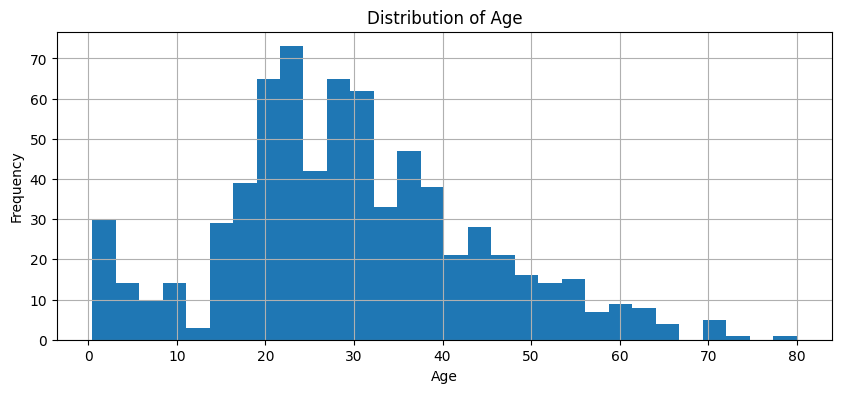

Proportions of missing values in Age feature per Pclass:
Pclass
1    0.138889
2    0.059783
3    0.276986
Name: Age, dtype: float64


In [9]:
plt.figure(figsize=(10, 4))
df_train['Age'].hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

print("Proportions of missing values in Age feature per Pclass:")
df_grouped = df_train.groupby('Pclass')['Age']
missing_values_proportion = df_grouped.apply(lambda x: x.isnull().mean())
print(missing_values_proportion)



We can see that the distribution resembles a normal distribution. We can also observe that the distribution of missing values varies across `Pclass`; let’s try replacing the missing values with the median for each `Pclass`.

For Embarked, since it is a categorical, we will replace the missing values with the most frequent value.

In [10]:
df_train_clean = df_train.drop(columns=['Name', 'PassengerId', 'Ticket', 'Cabin'])
df_test_clean = df_test.drop(columns=['Name', 'PassengerId', 'Ticket', 'Cabin'])

df_train_clean['Age'] = df_train.groupby(['Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df_test_clean['Age'] = df_test.groupby(['Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

embarked_mode = df_train_clean['Embarked'].mode()[0]
df_train_clean.fillna({'Embarked': embarked_mode}, inplace=True)
df_test_clean.fillna({'Embarked': embarked_mode}, inplace=True)

print(f"There are no missing values in the cleaned training dataset: {df_train_clean.isna().sum().sum() == 0}")


There are no missing values in the cleaned training dataset: True


Let's now check distribution of `Survived`.


In [11]:
print("Class distribution proportion:")
print(df_train_clean['Survived'].value_counts(normalize=True))

Class distribution proportion:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


So, we have 0.616/0.384 distribution, so we can use KFold for CV.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

`skrub.tabular_pipeline` automatically does preprocessing. For categorical features it uses `OneHotEncoder` (for features with less than 10 unique values) and `TargetEncoder` (otherwise). For numerical features applies `StandardScaler`. After that, `HistGradientBoostingClassifier` is used as a default model (since we set `classification` in definition of `tabular_pipeline`).

In [ ]:
from sklearn.model_selection import cross_validate, KFold
from skrub import tabular_pipeline

X_train = df_train_clean.drop('Survived', axis=1)
y_train = df_train_clean['Survived']
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist() 
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')


model = tabular_pipeline('classifier')

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(model, X_train, y_train, cv=cv, scoring='accuracy')
print(f"CV accuracy: {scores['test_score'].mean():.3f}, std error: {scores['test_score'].std():.3f})")


model.fit(X_train, y_train)
print(f"Train accuracy: {model.score(X_train, y_train):.3f}")

X_test = df_test_clean.drop(columns=['Survived'], errors='ignore')
for col in categorical_cols:
    X_test[col] = X_test[col].astype('category')
y_pred = model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': y_pred
})
submission.to_csv('submission.csv', index=False)


CV accuracy: 0.838, std error: 0.029)


For this preprocessed data, we got `0.758` public score on Kaggle. Let's improve it. 

Let's try to use several models and do ensambling. We will try `HistGradientBoostingClassifier`, `RandomForestClassifier`, `LogisticRegression`. To do this, we will use `sklearn.ensemble.VotingClassifier`. And we will also use `GridSearchCV` to find the good hyperparameters 

In [13]:
df_test_clean.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        1
Embarked    0
dtype: int64

We see, that in df_test_clean we have 1 missing value in `Fare`. `skrub` didn't encounter an error because it can handle NaN values on its own (using the same algorithm we used). We, however, will need to handle them in new code, since we are doing this manually. And we also add `Pipeline` to do all preprocessing and model fitting in one command for train and test sets

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
#import logistic regression to use it in ensemble
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

df_test_clean['Fare'] = df_test_clean['Fare'].fillna(df_test_clean['Fare'].median())

models = VotingClassifier(estimators=[
    ('hgb', HistGradientBoostingClassifier()),
    ('rf', RandomForestClassifier()),
    ('lr', LogisticRegression(max_iter=1000)),
], voting='soft')


pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])),
    ('classifier', models)
])

param_grid = {
    'classifier__hgb__max_iter': [100, 200],
    'classifier__hgb__max_depth': [3, 5,7],
    'classifier__rf__n_estimators': [100, 200],
    'classifier__rf__max_depth': [3, 5,7],
    'classifier__lr__C': [0.1, 1, 10],
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best CV accuracy: {grid_search.best_score_:.3f} with params: {grid_search.best_params_}")
pipeline = grid_search.best_estimator_


X_test = df_test_clean.drop(columns=['Survived'], errors='ignore')
# make submission
pipeline.fit(X_train, y_train)
y_pred_vote = pipeline.predict(X_test)
submission_vote = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': y_pred_vote
})
submission_vote.to_csv('submission_vote.csv', index=False)


Best CV accuracy: 0.845 with params: {'classifier__hgb__max_depth': 7, 'classifier__hgb__max_iter': 200, 'classifier__lr__C': 0.1, 'classifier__rf__max_depth': 3, 'classifier__rf__n_estimators': 100}


For this ensamble we got `0.779`, which is a quite good improvement.